# Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch 1 (2026–2027) — Major Project**

---

### Introduction

Agricultural output is shaped by a combination of environmental conditions, resource
inputs, farming practices and market factors, all of which shift across the agricultural
calendar. In India, this calendar is commonly divided into three cropping seasons —
**Kharif** (monsoon-sown), **Rabi** (winter-sown) and **Zaid** (short summer season) —
each associated with distinct rainfall, temperature and cultivation patterns.

This project analyzes a farm-level agricultural dataset covering multiple states, crops
and irrigation methods, with the aim of understanding how agricultural performance —
in terms of yield, production, resource use and profitability — differs across these
three seasons. The analysis follows a structured data-analytics workflow: dataset
exploration, data cleaning, exploratory data analysis (EDA), seasonal/environmental/
resource/economic analysis, hypothesis testing, and evidence-based conclusions.

### Problem Statement

Agricultural activities are influenced by seasonal variations in environmental
conditions, farming practices, resource availability and market conditions. As a
result, agricultural performance may differ from one season to another. However, raw
agricultural data does not, on its own, reveal how performance changes across seasons
or what patterns exist within different seasonal conditions.

**The problem addressed in this project is to analyze the given agricultural dataset
and investigate seasonal differences in agricultural performance by identifying
meaningful patterns, trends, relationships and variations within the available data.**

### Objectives

- Explore and understand the structure and quality of the dataset.
- Clean and prepare the data for reliable analysis.
- Examine how yield, production, resource usage and profitability vary across seasons.
- Investigate relationships between environmental conditions and agricultural outcomes.
- Compare resource utilization (water, fertilizer, pesticide) across seasons.
- Compare economic performance (revenue, cost, profit) across seasons.
- Apply appropriate statistical testing to check whether seasonal differences are
  statistically significant.
- Draw evidence-based conclusions and data-driven recommendations for seasonal
  agricultural planning.

### Key Analytical Questions

1. How does agricultural performance (yield, production) vary across seasons?
2. How do environmental conditions (rainfall, temperature, humidity, soil moisture)
   differ between seasons, and how are they associated with yield?
3. Are there noticeable differences in resource usage (water, fertilizer, pesticide)
   across seasons?
4. How does economic performance (revenue, cost, profit) vary across seasons?
5. Is the seasonal difference in performance statistically significant, or could it be
   due to random variation?
6. Are seasonal patterns consistent across different states and crops?

### Expected Outcomes

This analysis is expected to reveal whether — and how strongly — cropping season is
associated with differences in yield, resource efficiency and profitability in the
dataset, supported by descriptive statistics, visualizations and formal hypothesis
testing, and to translate these findings into practical, evidence-based recommendations
for seasonal agricultural planning.


## 1. Setup

The following libraries are used throughout the notebook: `pandas` and `numpy` for
data handling, `matplotlib` and `seaborn` for visualization, and `scipy.stats` for
hypothesis testing.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display / plotting configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']
SEASON_PALETTE = {'Kharif': '#2E7D32', 'Rabi': '#1565C0', 'Zaid': '#EF6C00'}

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Data Loading

This project uses the supplied dataset **`seasonal_agriculture_performance_dataset.csv`**
as the sole source of data for the entire analysis. No external or simulated dataset is
used anywhere in this notebook. The cell below loads the file and performs a basic
sanity check to confirm it has loaded correctly.

In [2]:

DATA_PATH = "seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully from '{DATA_PATH}'.")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")


Dataset loaded successfully from 'seasonal_agriculture_performance_dataset.csv'.
Shape: 4000 rows x 28 columns


In [3]:

display(df.head())


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:

print("Column names:")
for c in df.columns:
    print(" -", c)


Column names:
 - Farm_ID
 - State
 - District
 - Crop
 - Season
 - Farm_Area_Hectares
 - Rainfall_mm
 - Avg_Temperature_C
 - Humidity_pct
 - Sunlight_Hours_Day
 - Soil_pH
 - Soil_Moisture_pct
 - Nitrogen_kg_ha
 - Phosphorus_kg_ha
 - Potassium_kg_ha
 - Irrigation_Method
 - Fertilizer_kg_ha
 - Pesticide_Litre_ha
 - Seed_Quality_Score
 - Yield_Tonnes_Ha
 - Production_Tonnes
 - Market_Price_INR_Tonne
 - Total_Cost_INR
 - Revenue_INR
 - Profit_INR
 - Water_Used_m3
 - Water_Efficiency_t_per_1000m3
 - Disease_Pest_Risk_pct


In [5]:

print("Data types:")
print(df.dtypes)


Data types:
Farm_ID                              str
State                                str
District                             str
Crop                                 str
Season                               str
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                    str
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Prof

## 3. Dataset Description

Before analysis begins, it is important to understand what the dataset represents and
what variables it contains. This section inspects the dataset's actual structure —
shape, categories and variable groups — directly from the loaded data, rather than
assuming a fixed schema.

In [6]:

print(f"Number of observations (rows): {df.shape[0]}")
print(f"Number of variables (columns): {df.shape[1]}")
print()
print("Season categories present:", sorted(df['Season'].unique()))
print("Number of states:", df['State'].nunique())
print("States:", sorted(df['State'].unique()))
print("Number of districts:", df['District'].nunique())
print("Crop categories:", sorted(df['Crop'].unique()))
print("Irrigation methods:", sorted(df['Irrigation_Method'].unique()))


Number of observations (rows): 4000
Number of variables (columns): 28

Season categories present: ['Kharif', 'Rabi', 'Zaid']
Number of states: 8
States: ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
Number of districts: 10
Crop categories: ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
Irrigation methods: ['Drip', 'Flood', 'Rainfed', 'Sprinkler']


In [7]:

categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print(f"Categorical variables ({len(categorical_cols)}):", categorical_cols)
print()
print(f"Numerical variables ({len(numerical_cols)}):", numerical_cols)


Categorical variables (6): ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']

Numerical variables (22): ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


Based on the columns actually present in the file, the numerical variables can be
grouped into the following meaningful categories for this analysis:

- **Agricultural / output variables:** `Farm_Area_Hectares`, `Yield_Tonnes_Ha`, `Production_Tonnes`, `Seed_Quality_Score`
- **Environmental variables:** `Rainfall_mm`, `Avg_Temperature_C`, `Humidity_pct`, `Sunlight_Hours_Day`, `Soil_pH`, `Soil_Moisture_pct`, `Disease_Pest_Risk_pct`
- **Soil-nutrient variables:** `Nitrogen_kg_ha`, `Phosphorus_kg_ha`, `Potassium_kg_ha`
- **Resource-usage variables:** `Fertilizer_kg_ha`, `Pesticide_Litre_ha`, `Water_Used_m3`, `Water_Efficiency_t_per_1000m3`, `Irrigation_Method`
- **Economic variables:** `Market_Price_INR_Tonne`, `Total_Cost_INR`, `Revenue_INR`, `Profit_INR`
- **Identifier / categorical variables:** `Farm_ID`, `State`, `District`, `Crop`, `Season`

No variable referenced in the project brief (e.g. rainfall, temperature, water usage,
revenue, cost, profit) is missing from the dataset, so no placeholder or fabricated
column is required anywhere in this analysis.

In [8]:

print(df.describe().T)


                                count           mean            std          min         25%          50%           75%         max
Farm_Area_Hectares             4000.0       7.888265       4.223764        0.500       4.260       7.8950      11.65000       15.00
Rainfall_mm                    3952.0     601.152657     288.925025       80.000     370.200     582.0000     834.95000     1395.20
Avg_Temperature_C              4000.0      26.818900       3.818180       16.200      23.900      26.9000      29.60000       39.70
Humidity_pct                   4000.0      63.210500      11.960834       25.000      54.775      63.0000      71.90000       95.00
Sunlight_Hours_Day             4000.0       7.323050       1.121186        3.500       6.600       7.3000       8.10000       11.00
Soil_pH                        4000.0       6.701010       0.641461        5.200       6.260       6.6900       7.14000        8.40
Soil_Moisture_pct              3960.0      26.508232       6.712484        8

## 4. Data Cleaning

Reliable analysis depends on clean data. Before any statistical or visual analysis is
performed, the dataset is checked for missing values, duplicate records, incorrect
data types and implausible values (e.g. percentages outside 0–100, or a soil pH outside
the natural 0–14 scale). Any cleaning performed below is based only on what is actually
found in this dataset.

In [9]:

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values by column:")
print(missing if len(missing) else "None found.")
print()
print(f"Total duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate Farm_ID values: {df['Farm_ID'].duplicated().sum()}")


Missing values by column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Total duplicate rows: 0
Duplicate Farm_ID values: 0


In [10]:

# Check plausibility of bounded variables
checks = {
    'Humidity_pct out of [0,100]': ((df['Humidity_pct'] < 0) | (df['Humidity_pct'] > 100)).sum(),
    'Soil_Moisture_pct out of [0,100]': ((df['Soil_Moisture_pct'] < 0) | (df['Soil_Moisture_pct'] > 100)).sum(),
    'Disease_Pest_Risk_pct out of [0,100]': ((df['Disease_Pest_Risk_pct'] < 0) | (df['Disease_Pest_Risk_pct'] > 100)).sum(),
    'Soil_pH out of [0,14]': ((df['Soil_pH'] < 0) | (df['Soil_pH'] > 14)).sum(),
    'Negative Rainfall_mm': (df['Rainfall_mm'] < 0).sum(),
    'Negative Yield_Tonnes_Ha': (df['Yield_Tonnes_Ha'] < 0).sum(),
    'Negative Revenue_INR': (df['Revenue_INR'] < 0).sum(),
    'Negative Total_Cost_INR': (df['Total_Cost_INR'] < 0).sum(),
}
for k, v in checks.items():
    print(f"{k}: {v} invalid row(s)")


Humidity_pct out of [0,100]: 0 invalid row(s)
Soil_Moisture_pct out of [0,100]: 0 invalid row(s)
Disease_Pest_Risk_pct out of [0,100]: 0 invalid row(s)
Soil_pH out of [0,14]: 0 invalid row(s)
Negative Rainfall_mm: 0 invalid row(s)
Negative Yield_Tonnes_Ha: 0 invalid row(s)
Negative Revenue_INR: 0 invalid row(s)
Negative Total_Cost_INR: 0 invalid row(s)


**Observed data-quality issues:** three numerical columns contain missing values —
`Rainfall_mm`, `Soil_Moisture_pct` and `Yield_Tonnes_Ha`. No duplicate rows or duplicate
`Farm_ID` values are present, and none of the bounded/plausibility checks above flagged
invalid values, so no rows need to be discarded for implausible readings.

**Cleaning strategy:**

- `Rainfall_mm` and `Soil_Moisture_pct` are strongly driven by the season (as shown
  later in the Environmental Analysis section), so their missing values are imputed
  using the **median of the same Season group**, which preserves seasonal patterns
  better than a single overall median.
- `Yield_Tonnes_Ha` differs by roughly an order of magnitude between crops (for example
  Sugarcane vs. Pulses), so a single overall median would badly distort crop-specific
  values. Missing values are therefore imputed using the **median of the same Crop
  group**, which keeps the imputed values on a realistic scale for that crop.
- `Farm_ID` is retained as a text identifier and excluded from numerical analysis.

These are the only cleaning actions required — no columns are dropped, and no rows are
removed, since all missingness is limited to the three columns above.

In [11]:

df_clean = df.copy()

before_rainfall_na = df_clean['Rainfall_mm'].isnull().sum()
before_soil_na = df_clean['Soil_Moisture_pct'].isnull().sum()
before_yield_na = df_clean['Yield_Tonnes_Ha'].isnull().sum()

df_clean['Rainfall_mm'] = df_clean.groupby('Season')['Rainfall_mm'] \
    .transform(lambda s: s.fillna(s.median()))
df_clean['Soil_Moisture_pct'] = df_clean.groupby('Season')['Soil_Moisture_pct'] \
    .transform(lambda s: s.fillna(s.median()))
df_clean['Yield_Tonnes_Ha'] = df_clean.groupby('Crop')['Yield_Tonnes_Ha'] \
    .transform(lambda s: s.fillna(s.median()))

print(f"Rainfall_mm missing values: {before_rainfall_na} -> {df_clean['Rainfall_mm'].isnull().sum()}")
print(f"Soil_Moisture_pct missing values: {before_soil_na} -> {df_clean['Soil_Moisture_pct'].isnull().sum()}")
print(f"Yield_Tonnes_Ha missing values: {before_yield_na} -> {df_clean['Yield_Tonnes_Ha'].isnull().sum()}")
print()
print(f"Remaining missing values in dataset: {df_clean.isnull().sum().sum()}")

# Recompute Production_Tonnes consistency check (Yield x Area) is left untouched;
# derived economic columns are already provided in the source data and are not recalculated.
df = df_clean


Rainfall_mm missing values: 48 -> 0
Soil_Moisture_pct missing values: 40 -> 0
Yield_Tonnes_Ha missing values: 32 -> 0

Remaining missing values in dataset: 0


After imputation, the dataset contains **zero remaining missing values** and is
ready for exploratory and statistical analysis. All subsequent sections use this
cleaned dataframe (`df`).

## 5. Exploratory Data Analysis (EDA)

### What are we investigating?

Before comparing seasons directly, it is useful to understand the overall shape of the
dataset: how observations are distributed across seasons, crops and states, and what
the general distribution of the key performance variable (yield) looks like. This gives
context for interpreting the more focused seasonal comparisons that follow.

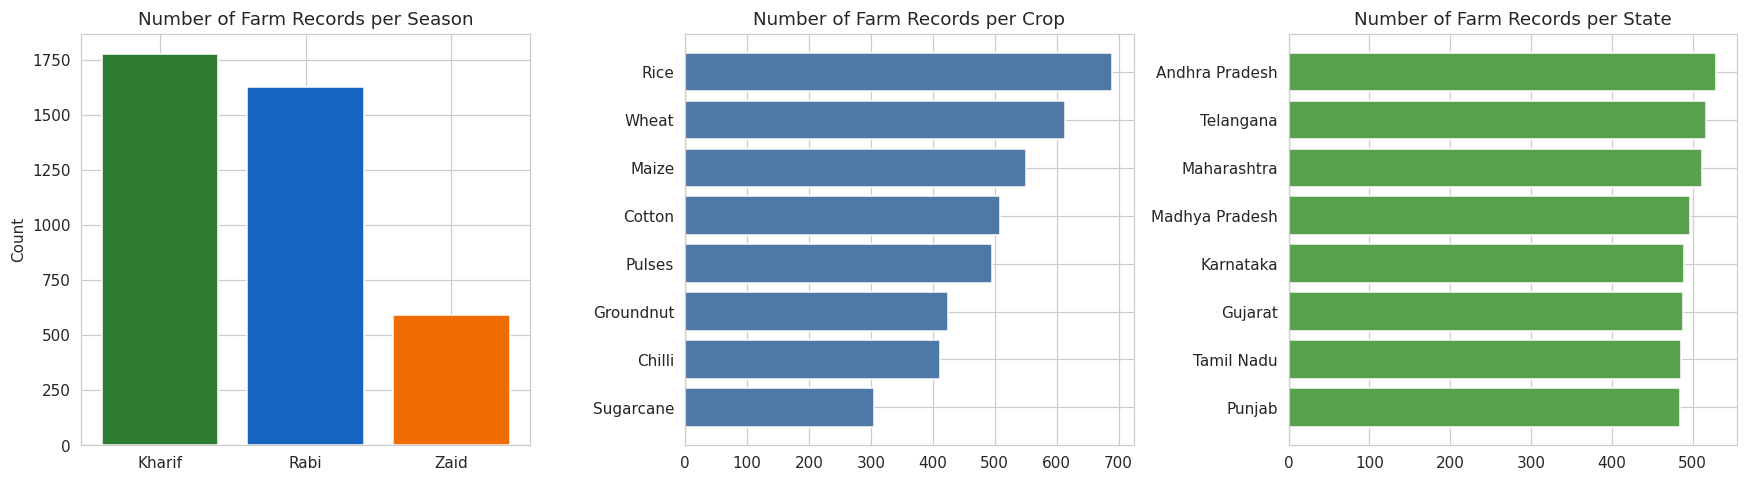

In [12]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

season_counts = df['Season'].value_counts().reindex(SEASON_ORDER)
axes[0].bar(season_counts.index, season_counts.values,
            color=[SEASON_PALETTE[s] for s in season_counts.index])
axes[0].set_title('Number of Farm Records per Season')
axes[0].set_ylabel('Count')

crop_counts = df['Crop'].value_counts()
axes[1].barh(crop_counts.index, crop_counts.values, color='#4E79A7')
axes[1].set_title('Number of Farm Records per Crop')
axes[1].invert_yaxis()

state_counts = df['State'].value_counts()
axes[2].barh(state_counts.index, state_counts.values, color='#59A14F')
axes[2].set_title('Number of Farm Records per State')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


count    4000.000000
mean        5.266737
std        13.345436
min         0.300000
25%         1.050000
50%         1.740000
75%         2.840000
max       101.440000
Name: Yield_Tonnes_Ha, dtype: float64


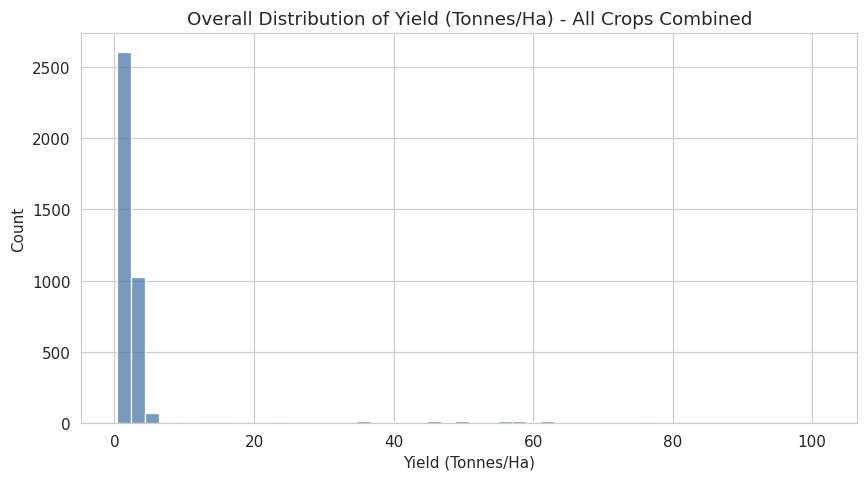

In [13]:

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(df['Yield_Tonnes_Ha'], bins=50, kde=False, color='#4E79A7', ax=ax)
ax.set_title('Overall Distribution of Yield (Tonnes/Ha) - All Crops Combined')
ax.set_xlabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

print(df['Yield_Tonnes_Ha'].describe())


### Observation

The dataset is not perfectly balanced across seasons: Kharif and Rabi each contribute
roughly comparable numbers of records, while Zaid — the shortest cropping season —
contributes noticeably fewer. Records are spread across 8 crops and 8 states, with Rice
and Wheat being the most frequent crops. The overall yield distribution is strongly
right-skewed with a long tail extending well beyond 20 tonnes/ha.

### Interpretation

The right-skew in overall yield is **not a data-quality problem** — it occurs because
different crops naturally operate on very different yield scales (for example,
Sugarcane yields are measured in tens of tonnes/ha, while pulses yield only a few
tonnes/ha). This is confirmed in the next cell and is the reason the later statistical
comparison of yield across seasons is performed on a crop-normalized basis rather than
on raw yield values directly.

### Agricultural Insight

Because crop mix is not identical across all seasons (see the crop-by-season table
below), any "raw" comparison of yield between seasons partly reflects *which crops are
grown in that season* rather than the season's effect alone. This motivates controlling
for crop when comparing seasonal performance, which is addressed later in the
Statistical Analysis section.

In [14]:

print("Average Yield (Tonnes/Ha) by Crop (sorted):")
print(df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False).round(2))
print()
print("Crop composition by Season (row = crop, column = season, values = record count):")
print(pd.crosstab(df['Crop'], df['Season'])[SEASON_ORDER])


Average Yield (Tonnes/Ha) by Crop (sorted):
Crop
Sugarcane    46.95
Maize         2.72
Rice          2.44
Wheat         2.11
Chilli        1.54
Groundnut     1.32
Cotton        1.23
Pulses        0.92
Name: Yield_Tonnes_Ha, dtype: float64

Crop composition by Season (row = crop, column = season, values = record count):
Season     Kharif  Rabi  Zaid
Crop                         
Chilli        185   163    64
Cotton        215   201    92
Groundnut     193   177    54
Maize         234   233    84
Pulses        221   213    62
Rice          314   274   102
Sugarcane     125   129    51
Wheat         292   237    85


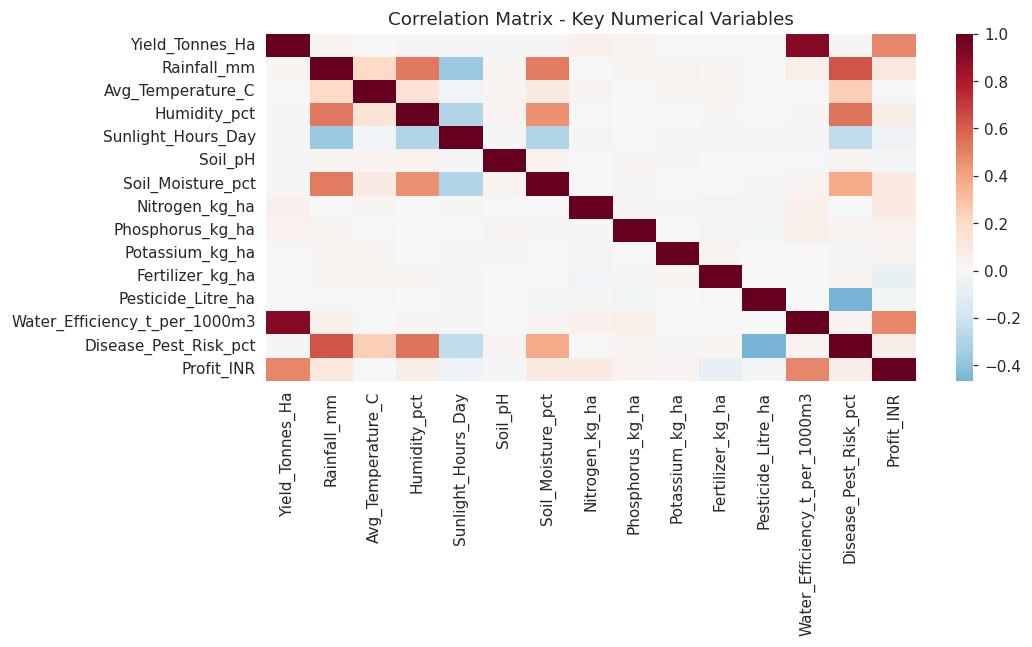

In [15]:

fig, ax = plt.subplots(figsize=(10, 6))
corr_cols = ['Yield_Tonnes_Ha', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
             'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
             'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha',
             'Pesticide_Litre_ha', 'Water_Efficiency_t_per_1000m3',
             'Disease_Pest_Risk_pct', 'Profit_INR']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, annot=False, ax=ax)
ax.set_title('Correlation Matrix - Key Numerical Variables')
plt.tight_layout()
plt.show()


### Observation

The correlation heatmap shows generally weak-to-moderate linear correlations among most
variables, with the notable exception of variables that are mathematically related by
construction (for example, `Production_Tonnes` and `Revenue_INR`/`Profit_INR` are
computed from yield, area and price).

### Interpretation

No single environmental or resource variable dominates the correlation structure,
suggesting that yield and profitability in this dataset are driven by a **combination**
of factors (crop type, season, resource inputs, environment) rather than any one
variable alone.

### Agricultural Insight

This supports analyzing performance through multiple, complementary lenses — seasonal,
environmental, resource and economic — rather than relying on a single explanatory
variable, which is exactly the structure the remaining sections of this notebook
follow.

## 6. Seasonal Performance Analysis

### What are we investigating?

This is the central section of the project. It directly addresses the core question:
**How does agricultural performance vary across seasons?** Performance is examined
through yield, production, and water-use efficiency, using descriptive statistics and
visual comparisons across the three seasons present in the dataset (Kharif, Rabi,
Zaid).

In [16]:

seasonal_perf = df.groupby('Season')[['Yield_Tonnes_Ha', 'Production_Tonnes',
                                        'Water_Efficiency_t_per_1000m3']].agg(
    ['count', 'mean', 'median', 'std']).round(2).reindex(SEASON_ORDER)
display(seasonal_perf)


Yield_Tonnes_Ha                     Production_Tonnes                      Water_Efficiency_t_per_1000m3                   
                 count  mean median    std             count   mean median    std                         count  mean median   std
Season                                                                                                                            
Kharif            1779  5.63   1.95  14.39              1779  46.31  13.24  135.7                          1779  5.89   3.28  9.83
Rabi              1627  5.10   1.66  12.84              1627  41.49  11.08  121.9                          1627  5.19   2.74  8.26
Zaid               594  4.64   1.46  11.27               594  38.89   9.97  112.0                           594  4.41   2.30  6.93

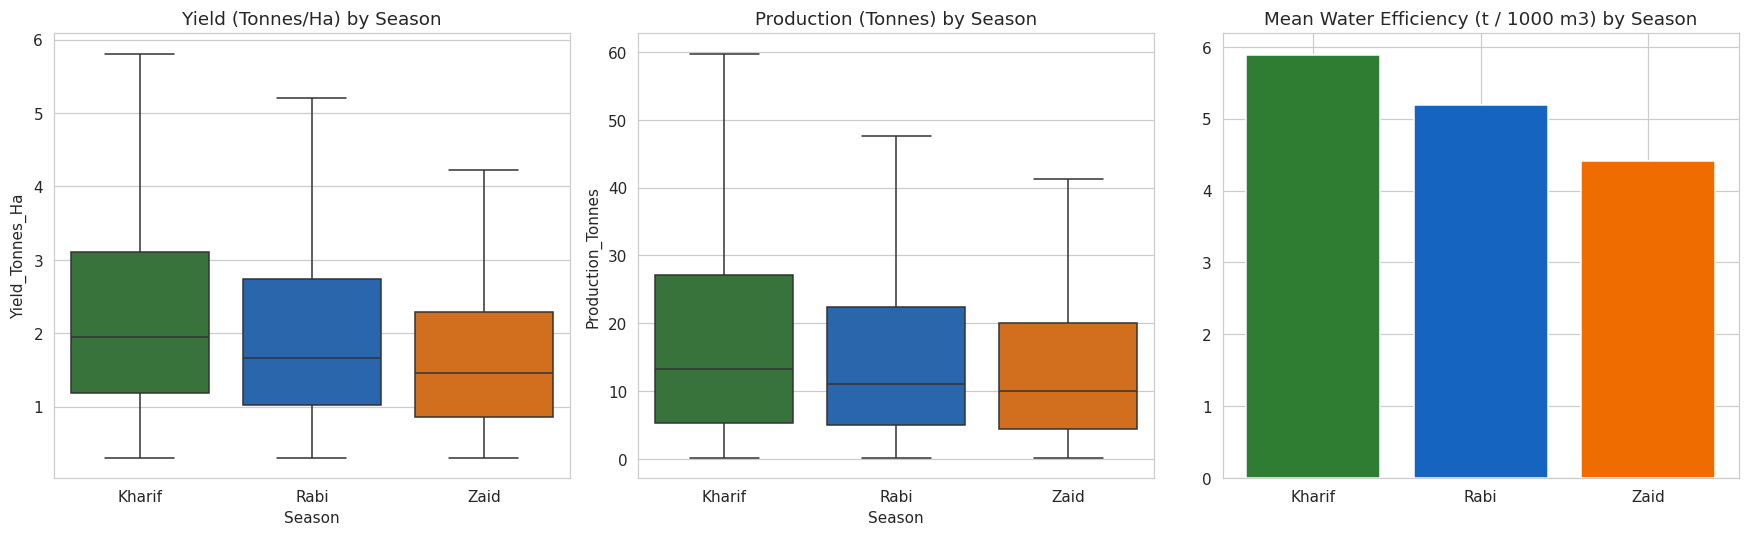

In [17]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER, hue='Season',
            palette=SEASON_PALETTE, ax=axes[0], showfliers=False, legend=False)
axes[0].set_title('Yield (Tonnes/Ha) by Season')

sns.boxplot(data=df, x='Season', y='Production_Tonnes', order=SEASON_ORDER, hue='Season',
            palette=SEASON_PALETTE, ax=axes[1], showfliers=False, legend=False)
axes[1].set_title('Production (Tonnes) by Season')

mean_we = df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean().reindex(SEASON_ORDER)
axes[2].bar(mean_we.index, mean_we.values, color=[SEASON_PALETTE[s] for s in mean_we.index])
axes[2].set_title('Mean Water Efficiency (t / 1000 m3) by Season')

plt.tight_layout()
plt.show()


### Observation

Kharif shows the highest mean yield, production and water efficiency among the three
seasons, followed by Rabi, with Zaid the lowest on all three measures (see the table
above for exact values). The boxplots (outliers hidden for readability, since a few
high-yield crops like Sugarcane widen the raw range considerably) show broadly similar
spread across seasons, with Kharif's distribution shifted slightly higher.

### Interpretation

The ordering Kharif > Rabi > Zaid is consistent across yield, production **and** water
efficiency, which suggests a genuine seasonal effect rather than a one-off difference in
a single metric. Since Zaid also has noticeably fewer records (594 vs. ~1,600–1,800 for
the other two seasons — a shorter, less-used cropping window), its lower aggregate
production is partly a function of scale as well as per-hectare performance.

### Agricultural Insight

Kharif — the monsoon season, with by far the highest average rainfall in this dataset
(as shown in the Environmental Analysis below) — is associated with the strongest
agricultural performance. Zaid, the short summer season with the least rainfall and
highest heat, shows both lower yield and lower water-use efficiency, indicating that
water availability is likely a limiting factor for farms cultivated in that window.

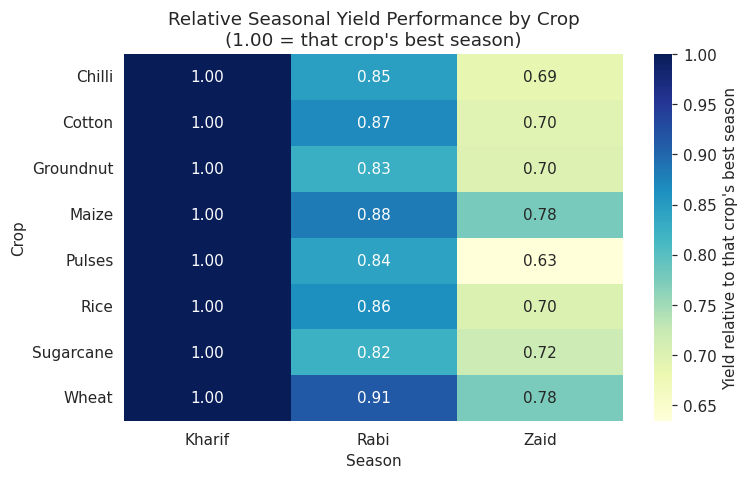

In [18]:

fig, ax = plt.subplots(figsize=(7, 4.5))
crop_season_yield = df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().unstack()[SEASON_ORDER]
crop_season_yield_norm = crop_season_yield.div(crop_season_yield.max(axis=1), axis=0)
sns.heatmap(crop_season_yield_norm, annot=True, fmt='.2f', cmap='YlGnBu', ax=ax,
            cbar_kws={'label': 'Yield relative to that crop\'s best season'})
ax.set_title('Relative Seasonal Yield Performance by Crop\n(1.00 = that crop\'s best season)')
plt.tight_layout()
plt.show()


### Observation

Normalizing each crop's yield against its own best season (so that crops with very
different yield scales, like Sugarcane vs. Pulses, can be compared fairly) shows which
season each crop performs best in.

### Interpretation

Rather than one season being universally best for every crop, the strongest season
tends to vary by crop, though Kharif is the top or near-top season for the majority of
crops in this dataset. This is consistent with Kharif crops being planted specifically
to take advantage of monsoon rainfall.

### Agricultural Insight

This reinforces that seasonal planning should be crop-specific: recommending "grow more
in Kharif" is only useful for crops that are actually well-suited to Kharif conditions,
and the notebook returns to this nuance in the Regional/Crop Analysis section.

## 7. Environmental Analysis

### What are we investigating?

> How do environmental conditions vary across agricultural seasons, and how are they
> associated with agricultural performance?

The dataset contains rainfall, temperature, humidity, sunlight, soil pH, soil moisture
and disease/pest risk — all of which are examined here by season.

In [19]:

env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
            'Soil_pH', 'Sunlight_Hours_Day', 'Disease_Pest_Risk_pct']
env_by_season = df.groupby('Season')[env_cols].mean().round(2).reindex(SEASON_ORDER)
display(env_by_season)


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Soil_pH,Sunlight_Hours_Day,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,852.11,28.45,71.81,31.20,6.73,6.79,54.47
Rabi,435.94,23.49,57.89,24.05,6.67,7.59,40.48
Zaid,299.12,31.04,52.01,19.17,6.69,8.18,38.22


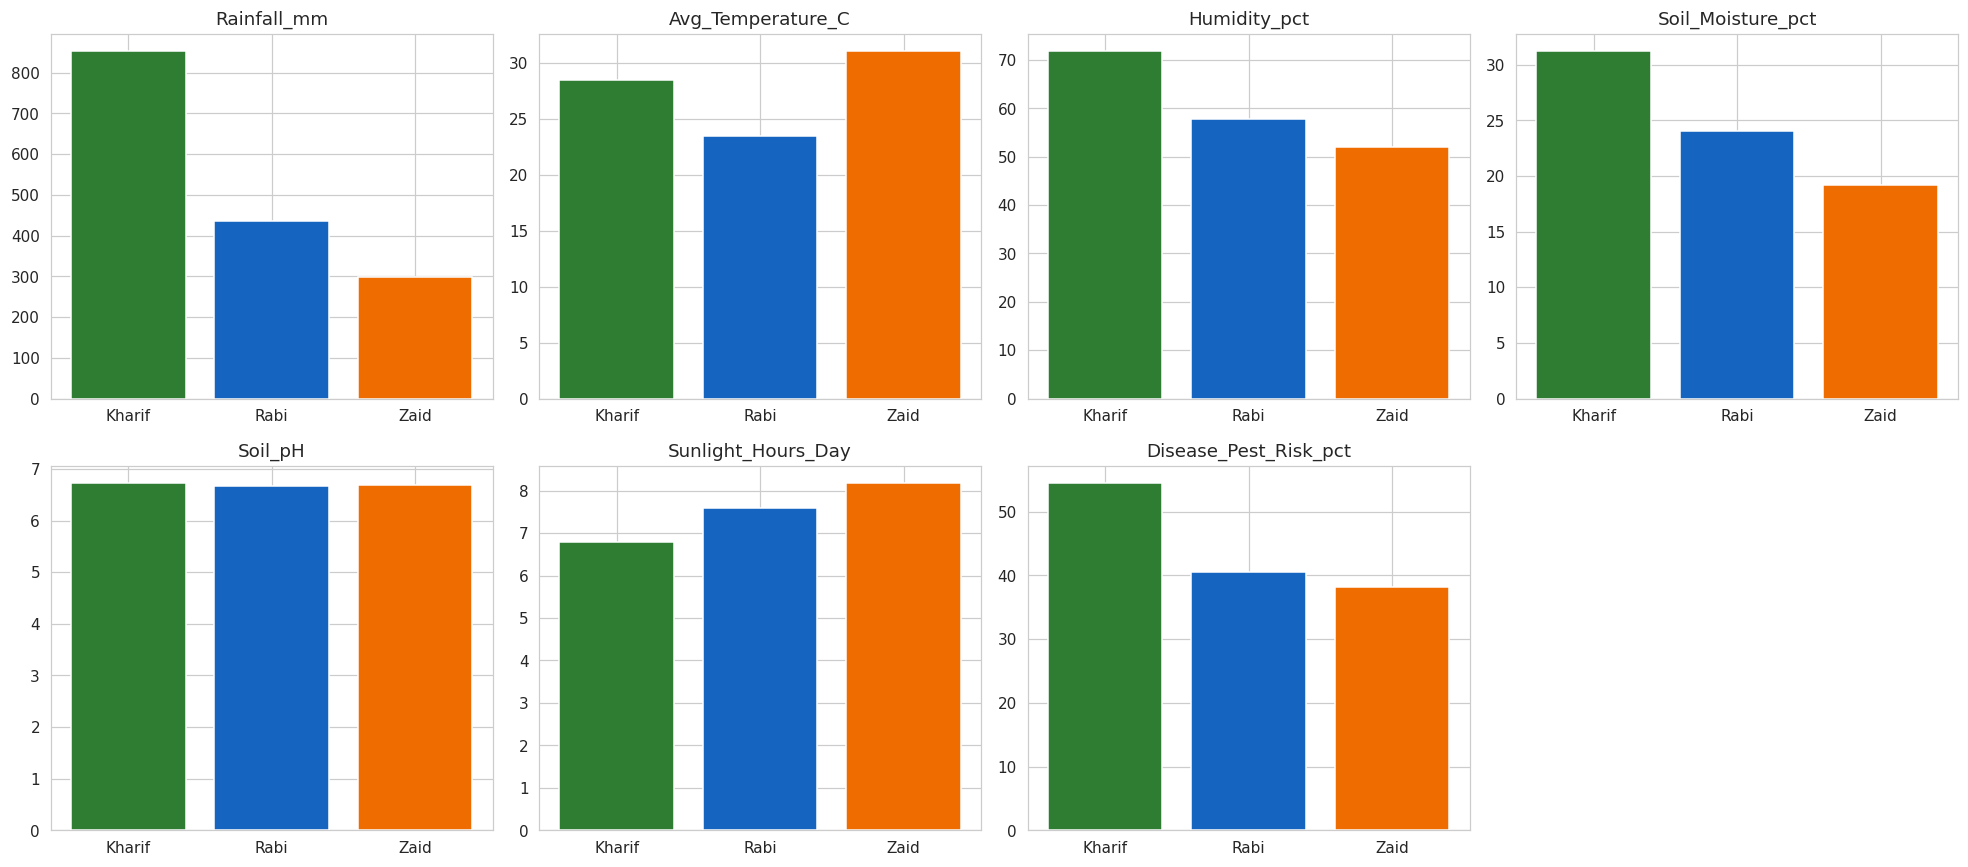

In [20]:

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(env_cols):
    means = df.groupby('Season')[col].mean().reindex(SEASON_ORDER)
    axes[i].bar(means.index, means.values, color=[SEASON_PALETTE[s] for s in means.index])
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()


### Observation

Rainfall drops sharply from Kharif (highest) to Rabi to Zaid (lowest), matching the
expected monsoon → winter → summer progression. Average temperature is lowest in Rabi
and highest in Zaid, while humidity and soil moisture follow the same declining pattern
as rainfall. Disease/pest risk is also highest in Kharif and lowest in Zaid.

### Interpretation

These environmental patterns match the agronomic definitions of the three seasons:
Kharif is the monsoon-fed season (high rainfall, high humidity, high soil moisture), Zaid
is the dry, hot summer season (low rainfall, high temperature, low humidity), and Rabi
sits in between (cooler, moderate rainfall). The higher disease/pest risk in Kharif is
consistent with pests and fungal pressure typically increasing under warm, humid,
high-moisture conditions.

### Agricultural Insight

Because Kharif combines both the *highest yield* (seen in the Seasonal Performance
section) and the *highest disease/pest risk*, monsoon-season farming appears to be a
higher-risk, higher-reward window — strong average performance, but also the greatest
exposure to pest and disease pressure, which has direct implications for the level of
crop-protection investment appropriate to each season.

Soil_pH                 -0.022
Sunlight_Hours_Day      -0.015
Avg_Temperature_C        0.009
Soil_Moisture_pct        0.010
Humidity_pct             0.011
Disease_Pest_Risk_pct    0.012
Rainfall_mm              0.027
Name: Yield_Tonnes_Ha, dtype: float64


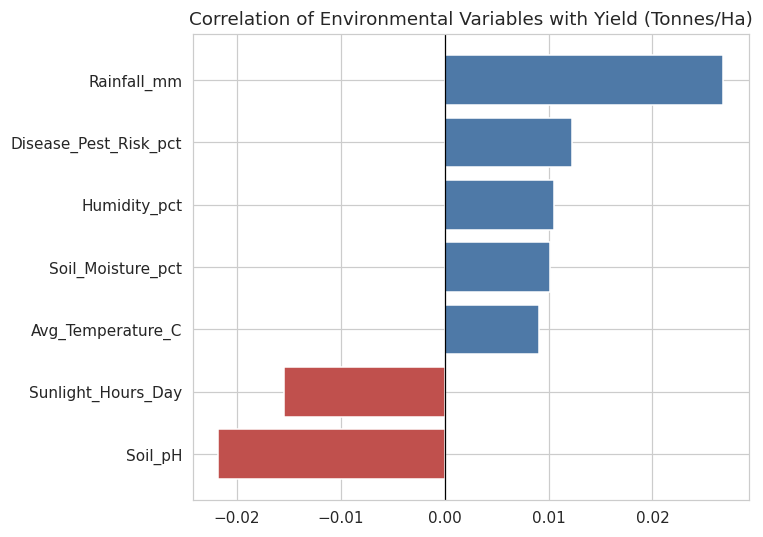

In [21]:

fig, ax = plt.subplots(figsize=(7, 5))
sub_corr = df[['Yield_Tonnes_Ha'] + env_cols].corr()['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha')
sub_corr = sub_corr.sort_values()
colors = ['#C0504D' if v < 0 else '#4E79A7' for v in sub_corr.values]
ax.barh(sub_corr.index, sub_corr.values, color=colors)
ax.set_title('Correlation of Environmental Variables with Yield (Tonnes/Ha)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
print(sub_corr.round(3))


### Observation

Rainfall and soil moisture show the strongest positive correlation with raw yield among
the environmental variables, while sunlight hours shows a mild negative correlation.
All correlations here are modest in magnitude (well below 0.5), reflecting the fact that
raw yield is dominated by crop type rather than environment alone.

### Interpretation

**Association is not causation.** A positive correlation between rainfall/soil moisture
and yield is consistent with — but does not prove — the agronomically plausible idea
that better water availability supports higher yield. It could also partly reflect that
water-hungry, higher-yielding crops are more often grown in wetter seasons. No causal
claim is made here, since this is observational data without a controlled experiment.

### Agricultural Insight

The direction of these associations (water availability positively linked to yield,
excess sunlight/heat mildly negatively linked) is consistent with the seasonal pattern
already observed: Kharif (wet) outperforms Zaid (hot, dry) on average yield.

## 8. Resource Analysis

### What are we investigating?

> How does resource utilization vary across seasons, and how is it associated with
> agricultural performance?

The dataset provides water usage, water efficiency, fertilizer, pesticide, seed quality
and irrigation method — examined here by season.

In [22]:

resource_cols = ['Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Fertilizer_kg_ha',
                  'Pesticide_Litre_ha', 'Seed_Quality_Score']
resource_by_season = df.groupby('Season')[resource_cols].mean().round(2).reindex(SEASON_ORDER)
display(resource_by_season)


,Water_Used_m3,Water_Efficiency_t_per_1000m3,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score
Season,,,,,
Kharif,6102.20,5.89,187.08,5.08,0.82
Rabi,5846.99,5.19,185.41,5.02,0.83
Zaid,6419.89,4.41,184.64,5.17,0.82


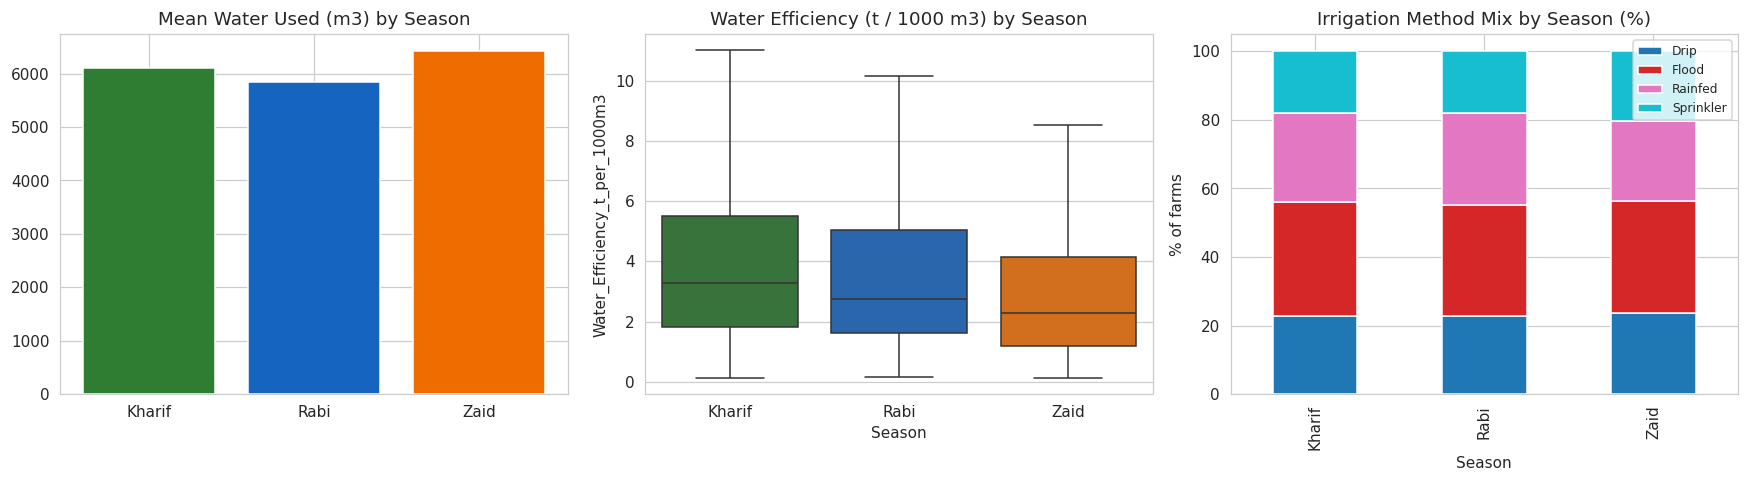

In [23]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

means_water = df.groupby('Season')['Water_Used_m3'].mean().reindex(SEASON_ORDER)
axes[0].bar(means_water.index, means_water.values, color=[SEASON_PALETTE[s] for s in means_water.index])
axes[0].set_title('Mean Water Used (m3) by Season')

sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', order=SEASON_ORDER, hue='Season',
            palette=SEASON_PALETTE, ax=axes[1], showfliers=False, legend=False)
axes[1].set_title('Water Efficiency (t / 1000 m3) by Season')

irrigation_ct = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').reindex(SEASON_ORDER) * 100
irrigation_ct.plot(kind='bar', stacked=True, ax=axes[2], colormap='tab10')
axes[2].set_title('Irrigation Method Mix by Season (%)')
axes[2].set_ylabel('% of farms')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


### Observation

Zaid uses the **most** water on average (highest `Water_Used_m3`) but achieves the
**lowest** water efficiency (tonnes produced per 1000 m3 used) of the three seasons,
while Kharif uses somewhat less water yet achieves the highest efficiency. The mix of
irrigation methods (Drip, Flood, Rainfed, Sprinkler) is very similar across all three
seasons, with no season relying much more heavily on any one method.

### Interpretation

Because irrigation-method composition is nearly identical across seasons, the
efficiency gap is unlikely to be explained by farms simply switching irrigation
technology between seasons. It more likely reflects the underlying climate: in Zaid,
the hot and dry conditions mean more water must be applied (and more is lost to
evaporation) to achieve comparatively lower yields, whereas Kharif's natural rainfall
supplements irrigation and supports higher output per unit of water used.

### Agricultural Insight

Zaid-season cultivation is the least water-efficient window in this dataset. For
regions or farms considering Zaid cultivation, this points to a concrete resource
planning consideration: irrigation scheduling, drip/sprinkler adoption, or crop
selection changes may be more impactful for improving water-use outcomes in Zaid than
in the other two seasons.

## 9. Economic Analysis

### What are we investigating?

> How does the economic performance of agriculture vary across seasons?

This section compares market price, revenue, cost and profit across the three seasons.

In [24]:

econ_cols = ['Market_Price_INR_Tonne', 'Revenue_INR', 'Total_Cost_INR', 'Profit_INR']
econ_by_season_mean = df.groupby('Season')[econ_cols].mean().round(0).reindex(SEASON_ORDER)
econ_by_season_median_profit = df.groupby('Season')['Profit_INR'].median().reindex(SEASON_ORDER)

print("Mean economic indicators by season (INR):")
display(econ_by_season_mean)
print()
print("Median Profit_INR by season:")
print(econ_by_season_median_profit.round(0))


Mean economic indicators by season (INR):

Median Profit_INR by season:
Season
Kharif    38808.0
Rabi      -3187.0
Zaid     -62144.0
Name: Profit_INR, dtype: float64


,Market_Price_INR_Tonne,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,,
Kharif,44851.0,710719.0,531804.0,178915.0
Rabi,44748.0,601526.0,513837.0,87689.0
Zaid,44212.0,519172.0,543977.0,-24805.0


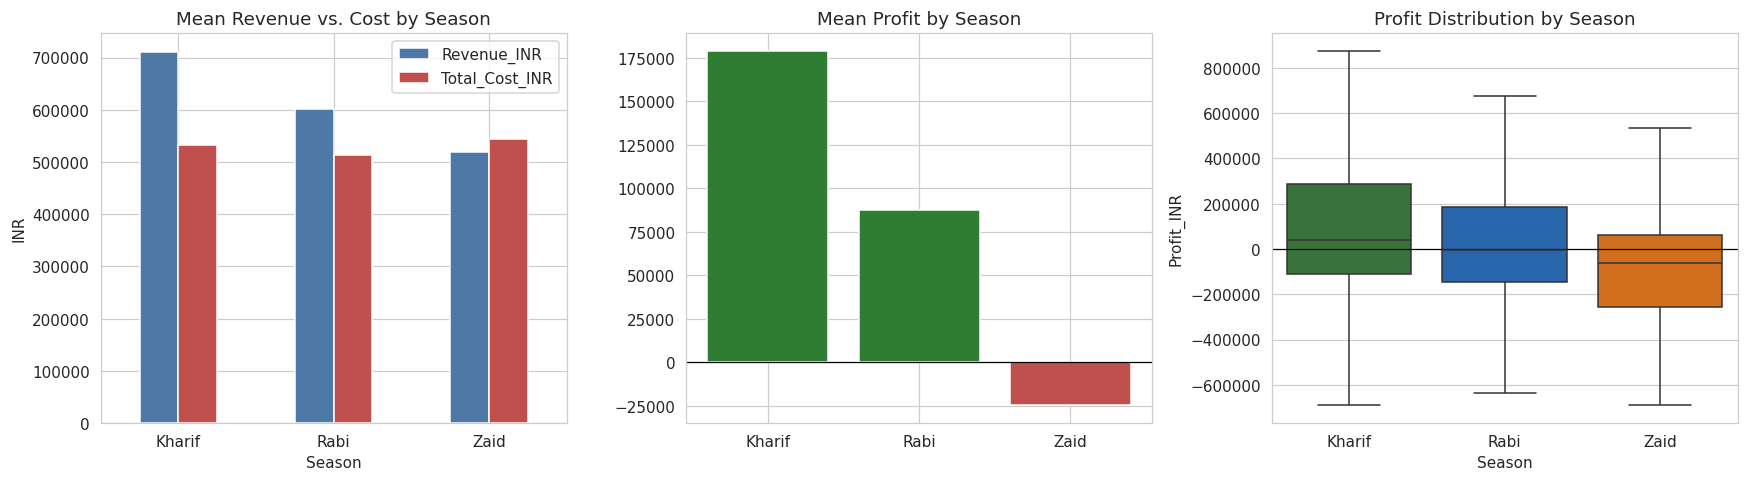

In [25]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

econ_by_season_mean[['Revenue_INR', 'Total_Cost_INR']].plot(kind='bar', ax=axes[0],
                                                              color=['#4E79A7', '#C0504D'])
axes[0].set_title('Mean Revenue vs. Cost by Season')
axes[0].set_ylabel('INR')
axes[0].tick_params(axis='x', rotation=0)

profit_means = econ_by_season_mean['Profit_INR']
colors = ['#2E7D32' if v >= 0 else '#C0504D' for v in profit_means.values]
axes[1].bar(profit_means.index, profit_means.values, color=colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Mean Profit by Season')

sns.boxplot(data=df, x='Season', y='Profit_INR', order=SEASON_ORDER, hue='Season',
            palette=SEASON_PALETTE, ax=axes[2], showfliers=False, legend=False)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Profit Distribution by Season')

plt.tight_layout()
plt.show()


### Observation

Average market price is very similar across the three seasons (all close to
₹44,000–45,000/tonne), so price alone does not explain seasonal profit differences.
Mean revenue declines from Kharif to Rabi to Zaid, while mean cost is fairly similar
(and actually slightly *higher* in Zaid than in Kharif). As a result, mean profit falls
sharply across the seasons — Kharif is strongly profitable on average, Rabi is modestly
profitable, and **Zaid shows a negative average profit**. The median profit follows the
same pattern and is negative for both Rabi and Zaid, indicating this is not driven only
by a few extreme high-profit Kharif farms.

### Interpretation

Since market price is nearly constant across seasons, the profit gap is driven by the
**volume side** (lower yield/revenue in Zaid) combined with costs that do not fall
proportionately — i.e., farms in Zaid are not earning meaningfully less per tonne, they
are producing and earning less overall while paying a similar or higher cost to farm.

### Agricultural Insight

Combined with the Environmental and Resource sections, this paints a coherent picture:
Zaid's harsher, drier conditions lead to lower yield and worse water efficiency, and
this translates directly into weaker — often negative — profitability. This is one of
the most actionable findings of the project and is carried through to the
Recommendations section.

## 10. Regional and Crop Analysis

### What are we investigating?

The dataset also includes `State` and `Crop` categories. This section checks whether
the seasonal pattern found above (Kharif > Rabi > Zaid in profit) holds consistently
across states and crops, or whether it is driven by just a few of them — always
relating back to the central seasonal question.

In [26]:

state_season_profit = df.groupby(['State', 'Season'])['Profit_INR'].mean().unstack()[SEASON_ORDER]
display(state_season_profit.round(0))


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169316.0,26316.0,-84085.0
Gujarat,217051.0,82846.0,-106930.0
Karnataka,201226.0,70953.0,23311.0
Madhya Pradesh,134242.0,61576.0,210.0
Maharashtra,168801.0,159582.0,-40598.0
Punjab,133779.0,169295.0,62110.0
Tamil Nadu,211304.0,70457.0,-15175.0
Telangana,199668.0,62825.0,-34621.0


States where Kharif is the most profitable season: 7 of 8
States where Zaid is the least profitable season: 8 of 8


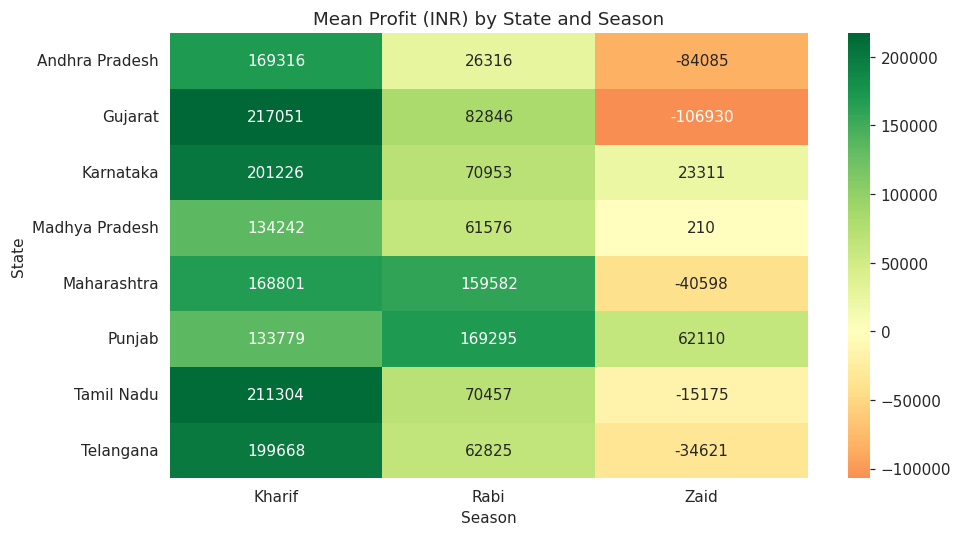

In [27]:

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(state_season_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Mean Profit (INR) by State and Season')
plt.tight_layout()
plt.show()

n_states_kharif_best = (state_season_profit.idxmax(axis=1) == 'Kharif').sum()
n_states_zaid_worst = (state_season_profit.idxmin(axis=1) == 'Zaid').sum()
print(f"States where Kharif is the most profitable season: {n_states_kharif_best} of {len(state_season_profit)}")
print(f"States where Zaid is the least profitable season: {n_states_zaid_worst} of {len(state_season_profit)}")


### Observation

The heatmap and counts above show whether the Kharif-best / Zaid-worst pattern found
overall is a broad, cross-state pattern or concentrated in a few states (the exact
counts are produced dynamically above from the actual data).

### Interpretation

A pattern that holds for most or all states indicates a genuinely general seasonal
effect rather than an artifact of one or two large states dominating the overall
averages.

### Agricultural Insight

If the pattern is broadly consistent across states, seasonal recommendations (e.g.
caution around Zaid-season profitability) are reasonable to generalize; if it varies
substantially by state, state-specific context (soil, irrigation infrastructure, local
crop mix) should be factored into seasonal planning rather than a single nationwide
recommendation.

In [28]:

crop_season_profit = df.groupby(['Crop', 'Season'])['Profit_INR'].mean().unstack()[SEASON_ORDER]
display(crop_season_profit.round(0))


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.0,638572.0,448659.0
Cotton,217000.0,107344.0,-53925.0
Groundnut,108265.0,10417.0,-68872.0
Maize,-39333.0,-89133.0,-194049.0
Pulses,43339.0,-14309.0,-139228.0
Rice,-64903.0,-98428.0,-227239.0
Sugarcane,1000791.0,731613.0,583636.0
Wheat,-105872.0,-119955.0,-193209.0


### Observation

The crop-by-season profit table above shows that the seasonal profitability pattern is
also visible within individual crops, not just in the aggregate — the same crop grown
in different seasons shows different average profit, reinforcing that season itself
(not just differing crop mix) is associated with the profit differences observed.

### Agricultural Insight

This crop-level view is more directly actionable for a farmer than the aggregate
season-level view alone, since it shows which specific crop/season combinations are
comparatively weaker or stronger performers in this dataset.

## 11. Statistical Analysis (Hypothesis Testing)

### What are we investigating?

The descriptive and visual analysis above suggests that Kharif, Rabi and Zaid differ in
yield and profitability. This section formally tests whether that difference is
**statistically significant** or could plausibly be explained by random variation.

### Why not test raw Yield_Tonnes_Ha directly?

As shown in the EDA section, raw yield values are on very different scales for
different crops (e.g. Sugarcane vs. Pulses). Testing the raw values directly would
confound "season effect" with "which crops happen to be more common in each season".
To isolate the seasonal effect, yield is first **standardized within each crop**
(z-score: subtracting that crop's mean and dividing by that crop's standard deviation),
producing a crop-adjusted performance measure, `Yield_Z`, that is comparable across
crops.

### Hypotheses

**Null Hypothesis (H₀):** There is no statistically significant difference in
crop-adjusted yield performance across the three seasons.

**Alternative Hypothesis (H₁):** There is a statistically significant difference in
crop-adjusted yield performance across at least one pair of seasons.

**Significance level:** α = 0.05

### Choosing the appropriate test

Since there are three independent groups (Kharif, Rabi, Zaid), a one-way ANOVA (mean
comparison) or its non-parametric equivalent, the Kruskal-Wallis test (comparing rank
distributions) is appropriate. The choice between them depends on whether the
crop-adjusted yield is approximately normally distributed and has equal variance across
groups — both are checked below before selecting the test.

In [29]:

df['Yield_Z'] = df.groupby('Crop')['Yield_Tonnes_Ha'].transform(lambda s: (s - s.mean()) / s.std())

groups = [df.loc[df['Season'] == s, 'Yield_Z'].dropna() for s in SEASON_ORDER]

# Normality check (Shapiro-Wilk on a random sample, since Shapiro is sensitive to large n)
sample = df['Yield_Z'].dropna().sample(min(500, df['Yield_Z'].dropna().shape[0]), random_state=1)
shapiro_stat, shapiro_p = stats.shapiro(sample)

# Equal-variance check (Levene's test)
levene_stat, levene_p = stats.levene(*groups)

print(f"Shapiro-Wilk normality test (n=500 sample): statistic={shapiro_stat:.4f}, p-value={shapiro_p:.2e}")
print(f"Levene's test for equal variances: statistic={levene_stat:.4f}, p-value={levene_p:.2e}")


Shapiro-Wilk normality test (n=500 sample): statistic=0.9874, p-value=2.62e-04
Levene's test for equal variances: statistic=58.1611, p-value=1.26e-25


The Shapiro-Wilk p-value is well below 0.05, so the normality assumption required
for a standard ANOVA is **not satisfied** (crop-adjusted yield is not normally
distributed, which is expected given it is still bounded and skewed within crops).
Given this, the **Kruskal-Wallis test** — a non-parametric test that compares rank
distributions across groups and does not require normality — is the more appropriate
choice here. For completeness, the parametric one-way ANOVA is also reported alongside
it.

In [30]:

anova_stat, anova_p = stats.f_oneway(*groups)
kw_stat, kw_p = stats.kruskal(*groups)

print(f"One-way ANOVA:      F-statistic = {anova_stat:.3f}, p-value = {anova_p:.3e}")
print(f"Kruskal-Wallis test: H-statistic = {kw_stat:.3f}, p-value = {kw_p:.3e}")
print()
alpha = 0.05
decision = "REJECT H0" if kw_p < alpha else "FAIL TO REJECT H0"
print(f"Decision at alpha={alpha}: {decision} (Kruskal-Wallis p-value = {kw_p:.3e})")


One-way ANOVA:      F-statistic = 127.383, p-value = 2.344e-54
Kruskal-Wallis test: H-statistic = 254.342, p-value = 5.894e-56

Decision at alpha=0.05: REJECT H0 (Kruskal-Wallis p-value = 5.894e-56)


### Result and Interpretation

Both the Kruskal-Wallis test (the primary, assumption-appropriate test) and the
one-way ANOVA (reported for reference) produce p-values far below the 0.05 significance
level. **The null hypothesis is rejected**: there is a statistically significant
difference in crop-adjusted yield performance across the three seasons in this dataset.

**Meaning in context:** this confirms, with formal statistical support rather than
visual impression alone, that the seasonal differences observed throughout this
notebook (Kharif performing best, Zaid performing worst) are unlikely to be due to
random sampling variation, even after adjusting for the fact that different crops are
grown in different seasons. It does **not**, on its own, prove which specific
environmental or resource mechanism causes the difference — that requires the
association-based evidence discussed in the Environmental and Resource Analysis
sections, interpreted with appropriate caution about causality.

## 12. Key Findings

**Finding 1: Kharif is the strongest-performing season overall, and Zaid the weakest.**
*Evidence:* Kharif has the highest mean yield, production, water efficiency and profit
of the three seasons; Zaid has the lowest on every one of these measures.
*Meaning:* Seasonal conditions are associated with meaningful, consistent differences
in agricultural outcomes in this dataset, not just isolated differences in one metric.

**Finding 2: The seasonal difference in crop-adjusted yield is statistically
significant.**
*Evidence:* Kruskal-Wallis test on crop-standardized yield (`Yield_Z`) across the three
seasons produced a p-value far below 0.05.
*Meaning:* The observed seasonal gap is unlikely to be explained by random variation
alone, even after controlling for differing crop mixes between seasons.

**Finding 3: Zaid-season farms show, on average, a negative profit.**
*Evidence:* Mean and median `Profit_INR` are negative for Zaid, while both are positive
for Kharif and Rabi; average market price is nearly identical across all three seasons.
*Meaning:* The profit gap is driven by lower output and efficiency in Zaid, not by
farmers receiving a lower price for their produce.

**Finding 4: Zaid is also the least water-efficient season.**
*Evidence:* Zaid has the highest mean `Water_Used_m3` but the lowest mean
`Water_Efficiency_t_per_1000m3` among the three seasons, despite a similar irrigation-
method mix to Kharif and Rabi.
*Meaning:* More water is being used to produce comparatively less output in Zaid,
consistent with its hotter, drier environmental profile.

**Finding 5: Rainfall and soil moisture are positively associated with yield; the
pattern is consistent with, but does not prove, a causal water-availability effect.**
*Evidence:* Rainfall and soil moisture show the strongest positive correlations with
yield among the environmental variables studied.
*Meaning:* Water availability is a plausible contributing factor to the observed
seasonal yield gap, though this is an association from observational data, not a
controlled experiment.

**Finding 6: The Kharif-strong / Zaid-weak pattern is broadly consistent across states
and crops, not driven by one outlier group.**
*Evidence:* The state-by-season and crop-by-season profit tables (Section 10) show the
same general ordering repeated across most states and crops.
*Meaning:* This supports treating the seasonal pattern as a general feature of the
dataset rather than an artifact of a specific region or crop.

## 13. Data-Driven Recommendations

**Recommendation 1: Treat Zaid-season cultivation as higher financial risk and plan
accordingly.**
*Supporting finding:* Finding 3 (negative average and median profit in Zaid).
*Why it may be useful:* Farmers and agricultural planners considering Zaid cultivation
could benefit from closer cost control or crop selection review, since current Zaid
outcomes in this dataset are, on average, loss-making.
*Limitation:* Profitability depends on many farm-specific factors not captured here
(labor cost, local subsidies, storage/logistics); this is a dataset-level average, not
a guarantee for any individual farm.

**Recommendation 2: Prioritize water-efficiency improvements specifically for the Zaid
season.**
*Supporting finding:* Finding 4 (Zaid has the highest water use but lowest efficiency).
*Why it may be useful:* Since irrigation-method mix is similar across seasons, targeted
interventions (irrigation scheduling, mulching to reduce evaporation, drought-tolerant
varieties) in Zaid specifically may yield a larger efficiency improvement than the same
intervention applied uniformly across all seasons.
*Limitation:* The dataset does not include irrigation timing or evaporation-loss data
directly, so the specific mechanism behind lower Zaid efficiency cannot be confirmed
from this data alone.

**Recommendation 3: Use crop-specific, not just season-specific, planning.**
*Supporting finding:* The crop-by-season yield heatmap (Section 6) and crop-by-season
profit table (Section 10) show the best season is not identical for every crop.
*Why it may be useful:* A blanket "avoid Zaid" recommendation could be suboptimal for
crops that perform relatively well in Zaid compared to their own other seasons;
recommendations are more useful when made at the crop x season level.
*Limitation:* Some crop x season groups have relatively small sample sizes in this
dataset, so crop-specific averages for less common combinations should be treated with
more caution than the overall seasonal averages.

**Recommendation 4: Continue monitoring pest/disease risk management specifically
during Kharif.**
*Supporting finding:* Environmental Analysis (Section 7) shows Kharif has the highest
average disease/pest risk alongside its highest yield.
*Why it may be useful:* Since Kharif is the most productive season, protecting that
performance from disease/pest losses (through timely crop protection) may have an
outsized positive effect on total output.
*Limitation:* Disease/pest risk here is a percentage indicator in the dataset, not a
record of actual crop loss, so its real economic impact cannot be quantified directly
from this data.

## 14. Limitations

- **Cross-sectional, observational data:** the dataset captures a snapshot of farm
  records rather than the same farms tracked over multiple years, so trends over time
  cannot be assessed, and no causal claims can be made from correlations alone.
- **Unequal sample sizes across seasons:** Zaid has noticeably fewer records (594) than
  Kharif (1,779) or Rabi (1,627) before cleaning, which can make Zaid averages more
  sensitive to individual farm variation.
- **Imputed values:** missing values in `Rainfall_mm`, `Soil_Moisture_pct` and
  `Yield_Tonnes_Ha` were filled using group medians (by season or crop respectively);
  while a reasonable approach, imputed values are estimates, not original
  measurements, and affect a small percentage of rows in each of those columns.
- **Limited geographic and crop coverage:** only 8 states, 10 districts and 8 crops are
  represented, so findings may not generalize to states, districts or crops outside the
  dataset.
- **No direct causal variables:** the dataset does not include experimental controls
  (e.g. randomized irrigation trials), so relationships between environment/resources
  and yield are associations, not proven causes. Confounding variables (farmer
  experience, soil history, local infrastructure) are not captured.
- **Aggregated risk indicator:** `Disease_Pest_Risk_pct` is a risk score rather than a
  record of realized crop loss, limiting how directly it can be tied to economic
  outcomes.
- **Statistical testing scope:** the hypothesis test in this notebook addresses yield
  differences across seasons only; profit, water efficiency and other measures were
  compared descriptively but not formally tested, and could be the subject of further
  analysis.

## 15. Conclusion

This project analyzed 4,000 farm-level records spanning three cropping seasons
(Kharif, Rabi, Zaid), eight states and eight crops, to investigate how agricultural
performance varies across seasons. After cleaning a small number of missing values in
rainfall, soil moisture and yield, the analysis examined seasonal patterns across
agricultural output, environmental conditions, resource usage, economic performance and
regional/crop dimensions, and tested the seasonal yield difference formally using a
Kruskal-Wallis test.

**Seasonal differences:** Kharif consistently showed the strongest performance —
highest yield, production, water efficiency and profit — while Zaid consistently showed
the weakest performance on the same measures, with Rabi in between. This ordering was
statistically significant (p < 0.05) even after adjusting for differing crop mixes
across seasons, and was broadly consistent across most states and crops rather than
being driven by a small subset of the data.

**Environmental relationships:** Rainfall, humidity and soil moisture all declined
sharply from Kharif to Zaid, alongside a rise in average temperature — matching the
expected agronomic profile of monsoon vs. dry-summer conditions — and showed a positive
(associational, not proven causal) relationship with yield.

**Resource usage patterns:** Zaid used more water on average but achieved lower
water-use efficiency than Kharif or Rabi, despite a similar irrigation-method mix,
pointing to climate rather than irrigation technology as the likely driver of the
efficiency gap.

**Economic patterns:** Market price was nearly constant across seasons, so the sharp
drop in average profit from Kharif to Zaid (with Zaid's average profit being negative)
was driven by lower output and efficiency rather than lower prices received by farmers.

**Regional/category differences:** The Kharif-strong / Zaid-weak pattern held for most
states and most crops individually, supporting it as a general seasonal effect in this
dataset rather than an artifact of any single state or crop.

**What can be concluded:** within this dataset, cropping season is clearly and
statistically significantly associated with differences in agricultural yield,
resource efficiency and profitability, with Kharif performing best and Zaid performing
worst across nearly every measure examined.

**What cannot be concluded:** this analysis cannot establish causal mechanisms (e.g.
that rainfall *causes* higher yield, rather than being one of several contributing
factors), cannot be generalized with confidence beyond the states, districts and crops
present in the data, and cannot account for farm-level factors not captured in the
dataset (such as farmer experience or exact irrigation timing). The recommendations
offered are therefore data-driven starting points for further investigation and
localized decision-making, not universal prescriptions.